# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [94]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Regression Model Evaluation

In [95]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)

In [96]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [97]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [112]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [99]:
# Your code here :
X = data.drop('MEDV', axis = 1)
y = data['MEDV']

In [100]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [101]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [102]:
# Splitting happening now 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) # for sanity check 

(404, 13) (102, 13) (404,) (102,)


## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [103]:
# Your code here :
model = LinearRegression()


In [104]:
# Training set 
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
print(y_train_pred)

[10.96952405 19.41196567 23.06419602 12.1470648  18.3738116  25.24677946
 20.77024774 23.90932632  7.81713319 19.60988098 21.8202963  27.59615864
 32.67986504 15.12308446 35.3964561  12.99688651 20.728181   28.30223542
 15.61724836 24.45143096  4.61794591 23.76681932 25.56178249 22.98928526
 24.5213025  34.06407919 19.71166707 39.11233072 14.62515846 24.81139885
 18.02332883 20.85836445  9.57577261 20.87246835 22.28583096 31.79327155
 31.04748307 15.70611763 17.01382935 28.23332703 24.27661276 16.88670215
  6.90720745 26.75808901 22.586493   17.53664716 13.77197016 41.04840929
 16.44690754 18.23531669 25.37038646 23.64581399 22.05322581 20.83620499
 16.93508273 22.797579   29.13333934  7.69310515 24.60571452 17.2358028
 21.10846551 25.15150324 27.33394823 21.30494963 41.5811902  19.19666651
 15.37955448 19.33545877 17.04687638 22.96801532 23.11094953 33.6977586
 22.77436405 20.28968381 25.35517813 31.02479125 33.05103792 28.44712333
  8.50926331  5.61220643 12.81228164 19.81854491 34.8

In [105]:
# Testing set 
y_test_pred = model.predict(X_test)
print(y_test_pred)

[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992 23.25442929
 17.66253818 14.34119    23.01320703 20.63245597 24.90850512 18.63883645
 -6.08842184 21.75834668 19.23922576 26.19319733 20.64773313  5.79472718
 40.50033966 17.61289074 27.24909479 30.06625441 11.34179277 24.16077616
 17.86058499 15.83609765 22.78148106 14.57704449 22.43626052 19.19631835
 22.43383455 25.21979081 25.93909562 17.70162434 16.76911711 16.95125411
 31.23340153 20.13246729 23.76579011 24.6322925  13.94204955 32.25576301
 42.67251161 17.32745046 27.27618614 16.99310991 14.07009109 25.90341861
 20.29485982 29.95339638 21.28860173 34.34451856 16.04739105 26.22562412
 39.53939798 22.57950697 18.84531367 32.72531661 25.0673037  12.88628956
 22.68221908 30.48287757 31.52626806 15.90148607 20.22094826 16.71089812
 20.52384893 25.96356264 30.61607978 11.59783023 20.51232627 27.48111878
 11.01962332 15.68096344 23.79316251  6.19929359 21.6039073  41.41377225
 18.76548695  8.87931901 20.83076916 13.25620627 20

## 3. Calculate and print R-squared for both the training and the testing set.

In [106]:
# Your code here :

#training 
R_squared_training = r2_score(y_train, y_train_pred)
print(f"The R-squared for the training set is:", R_squared_training)


The R-squared for the training set is: 0.7508856358979673


In [107]:
# testing
R_squared_testing = r2_score(y_test, y_test_pred)
print(f"The R-squared for the testing set is:", R_squared_testing)

The R-squared for the testing set is: 0.6687594935356317


## 4. Calculate and print mean squared error for both the training and the testing set.

In [113]:
# Your code here :
MSE_training = mean_squared_error(y_train, y_train_pred)
print(f"The mean squared error for the training set is:", MSE_training)
MSE_testing = mean_squared_error(y_test, y_test_pred)
print(f"The mean squared error for the testing set is:", MSE_testing)

The mean squared error for the training set is: 21.641412753226312
The mean squared error for the testing set is: 24.291119474973538


## 5. Calculate and print mean absolute error for both the training and the testing set.

In [114]:
# Your code here :
MAE_training = mean_absolute_error(y_train, y_train_pred)
print(f"The mean absolute error for the training set is:", MAE_training)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The mean absolute error for the testing set is:", MAE_testing)


The mean absolute error for the training set is: 3.3147716267832252
The mean absolute error for the testing set is: 3.1890919658878416


## Classification Model Evaluation

In [115]:
from sklearn.datasets import load_iris
data = load_iris()

In [116]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [117]:
column_names = data.feature_names

In [118]:
df = pd.DataFrame(data['data'],columns=column_names)

In [119]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [120]:
target = pd.DataFrame(data.target)

In [121]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [122]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [123]:
# Your code here :
y_iris = target
X_iris = df

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=.2, random_state= 42)

In [125]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) # for sanity check 

(120, 4) (30, 4) (120, 1) (30, 1)


## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [128]:
from sklearn.linear_model import LogisticRegression

In [129]:
# Your code here :

# training 
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [130]:
y_training_pred = log_reg.predict(X_train)
print(y_training_pred)

[0 0 1 0 0 2 1 0 0 0 2 1 1 0 0 1 2 2 1 2 1 2 1 0 2 1 0 0 0 1 2 0 0 0 1 0 1
 2 0 1 2 0 2 2 1 1 2 1 0 1 2 0 0 1 2 0 2 0 0 2 1 2 2 2 2 1 0 0 2 2 0 0 0 1
 2 0 2 2 0 1 1 2 1 2 0 2 1 2 1 1 1 0 1 1 0 1 2 2 0 1 2 2 0 2 0 1 2 2 1 2 1
 1 2 2 0 1 2 0 1 2]


In [131]:
y_testing_pred = log_reg.predict(X_test)
print(y_testing_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


## 8. Calculate and print the accuracy score for both the training and the testing set.

In [132]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

In [133]:
# Your code here :

# Training 
print("Logistic Regression Report For Training Set:\n", classification_report(y_train, y_training_pred))
print("The accuracy score for the Training Set is:", accuracy_score(y_train, y_training_pred))

Logistic Regression Report For Training Set:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      0.93      0.96        41
           2       0.93      1.00      0.96        39

    accuracy                           0.97       120
   macro avg       0.98      0.98      0.97       120
weighted avg       0.98      0.97      0.97       120

The accuracy score for the Training Set is: 0.975


In [134]:
# Testing
print("Logistic Regression Report For Testing Set:\n", classification_report(y_test, y_testing_pred))
print("The accuracy score for the Testing Set is:", accuracy_score(y_test, y_testing_pred))

Logistic Regression Report For Testing Set:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

The accuracy score for the Testing Set is: 1.0


## 9. Calculate and print the balanced accuracy score for both the training and the testing set.

In [135]:
from sklearn.metrics import balanced_accuracy_score

In [136]:
# Your code here :

# Training set 
print(f"The balance accuracy score for the training set is", balanced_accuracy_score(y_train, y_training_pred))

# Testing set 
print(f"The balance accuracy score for the testing set is", balanced_accuracy_score(y_test, y_testing_pred))

The balance accuracy score for the training set is 0.975609756097561
The balance accuracy score for the testing set is 1.0


## 10. Calculate and print the precision score for both the training and the testing set.

In [137]:
from sklearn.metrics import precision_score

In [138]:
# Your code here :

# Training set 
print(f"The precision score for the training set is", precision_score(y_train, y_training_pred, average='macro'))

# Testing set 
print(f"The precision score for the testing set is", precision_score(y_test, y_testing_pred, average='macro'))

The precision score for the training set is 0.9761904761904763
The precision score for the testing set is 1.0


## 11. Calculate and print the recall score for both the training and the testing set.

In [139]:
from sklearn.metrics import recall_score

In [140]:
# Your code here :

# Training Set
print(f"The recall score for the training set is", recall_score(y_train, y_training_pred, average='macro'))

# Testing set 
print(f"The recall score for the testing set is", recall_score(y_test, y_testing_pred, average='macro'))

The recall score for the training set is 0.975609756097561
The recall score for the testing set is 1.0


## 12. Calculate and print the F1 score for both the training and the testing set.

In [141]:
from sklearn.metrics import f1_score

In [142]:
# Your code here :

# Training Set
print(f"The F1 score for the training set is", f1_score(y_train, y_training_pred, average='macro'))

# Testing set 
print(f"The F1 score for the testing set is", f1_score(y_test, y_testing_pred, average='macro'))

The F1 score for the training set is 0.974996093139553
The F1 score for the testing set is 1.0


## 13. Generate confusion matrices for both the training and the testing set.

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

Confusion Matrix of the Training Set:
 [[40  0  0]
 [ 0 38  3]
 [ 0  0 39]]


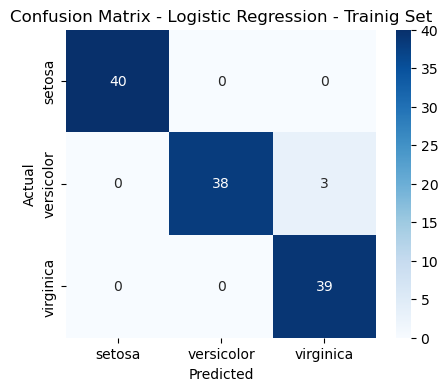

In [144]:
# Your code here :

# Training Set 
cm_training = confusion_matrix(y_train, y_training_pred)
print("Confusion Matrix of the Training Set:\n", cm_training)

plt.figure(figsize=(5,4))
sns.heatmap(cm_training, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression - Trainig Set")
plt.show()

Confusion Matrix of the Testing Set:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


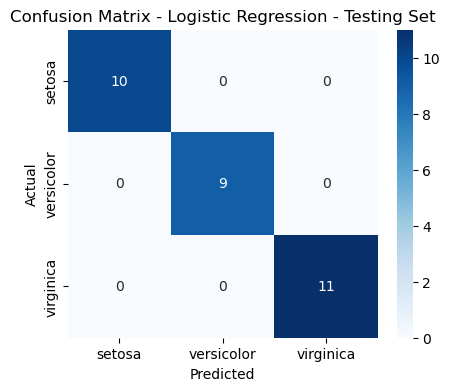

In [145]:
# Testing set
cm_testing = confusion_matrix(y_test, y_testing_pred)
print("Confusion Matrix of the Testing Set:\n", cm_testing)

plt.figure(figsize=(5,4))
sns.heatmap(cm_testing, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression - Testing Set")
plt.show()

## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

In [ ]:
# Have fun here !